In [3]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import cv2
import numpy as np

print(cv2.__version__)
print(np.__version__)


4.12.0
2.3.5


In [7]:
pip install numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


BRAIN MRI DATASET PREPROCESSING
Dataset extracted to 'original_dataset'

DATASET STRUCTURE
original_dataset/
  Testing/
    glioma/
      └─ 300 images
    meningioma/
      └─ 306 images
    notumor/
      └─ 405 images
    pituitary/
      └─ 300 images
  Training/
    glioma/
      └─ 1321 images
    meningioma/
      └─ 1339 images
    notumor/
      └─ 1595 images
    pituitary/
      └─ 1457 images

BEFORE RESIZING:
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images
Total images: 5712
Processed 100 images...
Processed 200 images...
Processed 300 images...
Processed 400 images...
Processed 500 images...
Processed 600 images...
Processed 700 images...
Processed 800 images...
Processed 900 images...
Processed 1000 images...
Processed 1100 images...
Processed 1200 images...
Processed 1300 images...
Processed 1400 images...
Processed 1500 images...
Processed 1600 images...
Processed 1700 images...
Processed 1800 images...
Processed 1900 images...
P

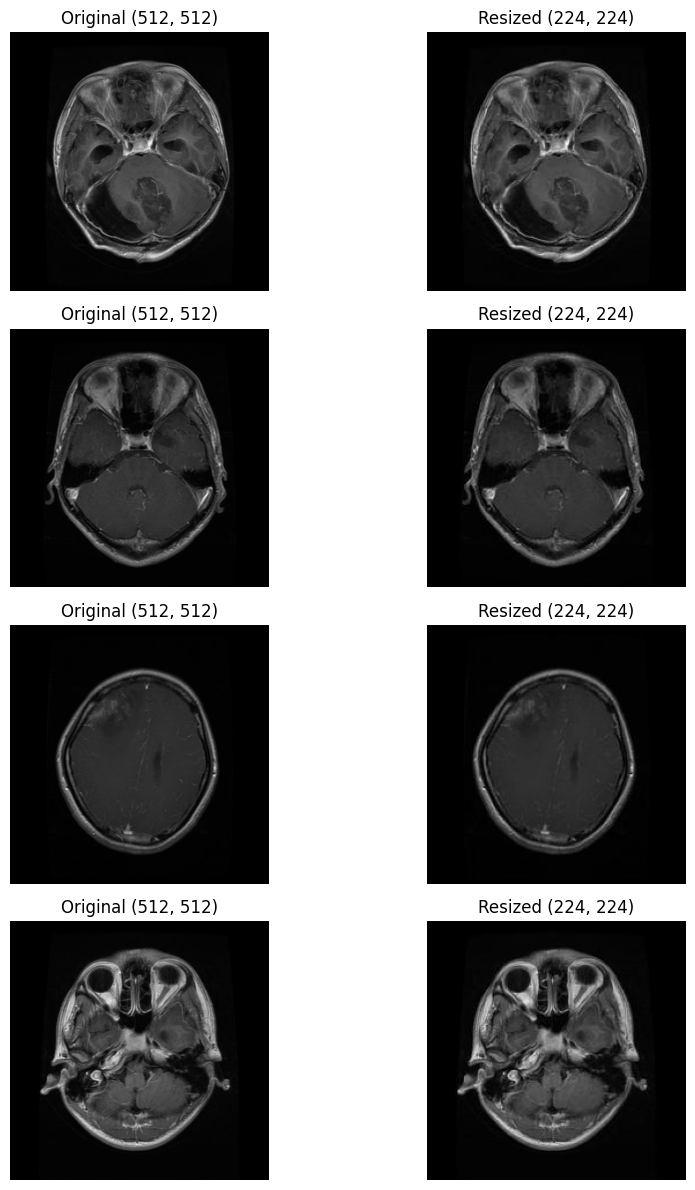

Visualization saved as 'comparison.png'

Preprocessing done! Resized dataset at 'resized_dataset'


In [8]:
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def extract_dataset(zip_path, extract_to='dataset'):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Dataset extracted to '{extract_to}'")
    return extract_to

def explore_dataset(path):
    print("\nDATASET STRUCTURE")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = '  ' * (level + 1)
        images = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if images: print(f"{sub_indent}└─ {len(images)} images")

def resize_images(src, tgt, size=(224,224)):
    if os.path.exists(tgt): shutil.rmtree(tgt)
    os.makedirs(tgt)
    total = 0
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                rel_path = os.path.relpath(root, src)
                target_sub = os.path.join(tgt, rel_path)
                os.makedirs(target_sub, exist_ok=True)
                try:
                    img = Image.open(os.path.join(root,file))
                    img.resize(size, Image.LANCZOS).save(os.path.join(target_sub,file))
                    total += 1
                    if total % 100 == 0: print(f"Processed {total} images...")
                except: pass
    print(f"Resized {total} images to {size}")
    return total

def visualize_comparison(orig_folder, resized_folder, samples=4):
    imgs = []
    for root, dirs, files in os.walk(orig_folder):
        for file in files:
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                imgs.append(os.path.join(root,file))
                if len(imgs)>=samples: break
        if len(imgs)>=samples: break

    fig, axes = plt.subplots(samples, 2, figsize=(10, samples*3))
    for idx, orig_path in enumerate(imgs):
        rel = os.path.relpath(orig_path, orig_folder)
        resized_path = os.path.join(resized_folder, rel)
        orig_img, resized_img = Image.open(orig_path), Image.open(resized_path)
        axes[idx,0].imshow(orig_img, cmap='gray'); axes[idx,0].set_title(f'Original {orig_img.size}'); axes[idx,0].axis('off')
        axes[idx,1].imshow(resized_img, cmap='gray'); axes[idx,1].set_title(f'Resized {resized_img.size}'); axes[idx,1].axis('off')
    plt.tight_layout(); plt.savefig('comparison.png', dpi=150); plt.show()
    print("Visualization saved as 'comparison.png'")

def dataset_stats(folder):
    stats = {}
    for root, dirs, files in os.walk(folder):
        images = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if images and os.path.basename(root): stats[os.path.basename(root)] = len(images)
    for k,v in stats.items(): print(f"{k}: {v} images")
    print(f"Total images: {sum(stats.values())}")
    return stats

# ===== MAIN EXECUTION =====
ZIP_FILE = "C:/Users/hp/Downloads/SmartScan_phase1/archive.zip"
EXTRACT_FOLDER = "original_dataset"
RESIZED_FOLDER = "resized_dataset"
TARGET_SIZE = (224,224)

print("BRAIN MRI DATASET PREPROCESSING")

dataset_path = extract_dataset(ZIP_FILE, EXTRACT_FOLDER)
explore_dataset(dataset_path)
print("\nBEFORE RESIZING:"); dataset_stats(dataset_path)
total_resized = resize_images(dataset_path, RESIZED_FOLDER, TARGET_SIZE)
print("\nAFTER RESIZING:"); dataset_stats(RESIZED_FOLDER)
visualize_comparison(dataset_path, RESIZED_FOLDER, samples=4)
print(f"\nPreprocessing done! Resized dataset at '{RESIZED_FOLDER}'")


IMAGE NORMALIZATION - PHASE 1
Normalized 100 images...
Normalized 200 images...
Normalized 300 images...
Normalized 400 images...
Normalized 500 images...
Normalized 600 images...
Normalized 700 images...
Normalized 800 images...
Normalized 900 images...
Normalized 1000 images...
Normalized 1100 images...
Normalized 1200 images...
Normalized 1300 images...
Normalized 1400 images...
Normalized 1500 images...
Normalized 1600 images...
Normalized 1700 images...
Normalized 1800 images...
Normalized 1900 images...
Normalized 2000 images...
Normalized 2100 images...
Normalized 2200 images...
Normalized 2300 images...
Normalized 2400 images...
Normalized 2500 images...
Normalized 2600 images...
Normalized 2700 images...
Normalized 2800 images...
Normalized 2900 images...
Normalized 3000 images...
Normalized 3100 images...
Normalized 3200 images...
Normalized 3300 images...
Normalized 3400 images...
Normalized 3500 images...
Normalized 3600 images...
Normalized 3700 images...
Normalized 3800 i

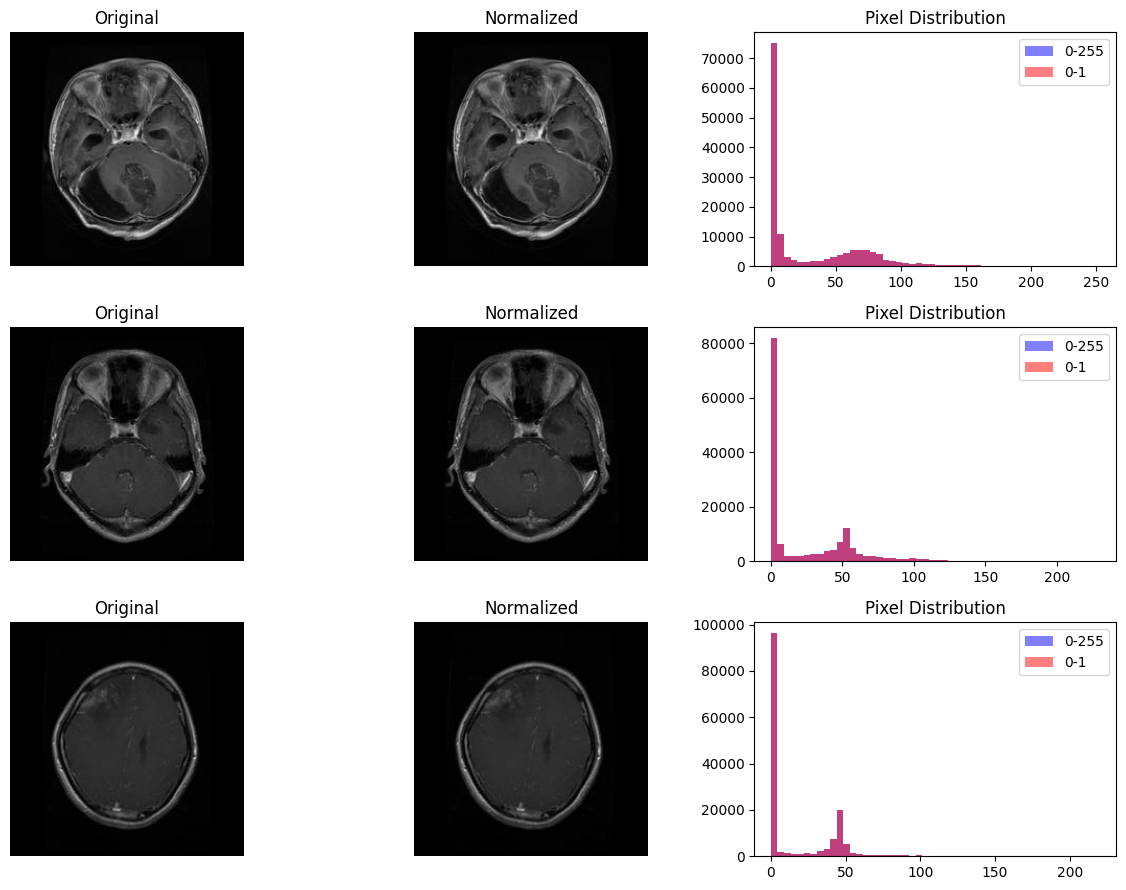

✓ Visualization saved as 'normalization_comparison.png'

Normalized dataset saved at 'normalized_dataset' with 7019 images


In [10]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def normalize_and_save(src, tgt):
    if not os.path.exists(tgt): os.makedirs(tgt)
    total = 0
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                rel = os.path.relpath(root, src)
                target_sub = os.path.join(tgt, rel)
                os.makedirs(target_sub, exist_ok=True)
                img = Image.open(os.path.join(root,file)).convert('RGB')
                arr = np.array(img)/255.0
                np.save(os.path.join(target_sub, file.rsplit('.',1)[0]+'.npy'), arr)
                total += 1
                if total % 100 == 0: print(f"Normalized {total} images...")
    print(f"✓ Normalized {total} images! Saved to '{tgt}'")
    return total

def visualize_normalization(resized_folder, normalized_folder, samples=3):
    imgs = []
    for root, dirs, files in os.walk(resized_folder):
        for file in files:
            if file.lower().endswith(('.png','.jpg','.jpeg')):
                imgs.append(os.path.join(root,file))
                if len(imgs)>=samples: break
        if len(imgs)>=samples: break

    fig, axes = plt.subplots(samples, 3, figsize=(12, samples*3))
    for idx, img_path in enumerate(imgs):
        orig = np.array(Image.open(img_path).convert('RGB'))
        rel = os.path.relpath(img_path, resized_folder)
        norm = np.load(os.path.join(normalized_folder, rel.rsplit('.',1)[0]+'.npy'))
        axes[idx,0].imshow(orig); axes[idx,0].set_title('Original'); axes[idx,0].axis('off')
        axes[idx,1].imshow(norm); axes[idx,1].set_title('Normalized'); axes[idx,1].axis('off')
        axes[idx,2].hist(orig.flatten(), bins=50, alpha=0.5, color='blue', label='0-255')
        axes[idx,2].hist((norm*255).flatten(), bins=50, alpha=0.5, color='red', label='0-1')
        axes[idx,2].set_title('Pixel Distribution'); axes[idx,2].legend()
    plt.tight_layout(); plt.savefig('normalization_comparison.png', dpi=150); plt.show()
    print("✓ Visualization saved as 'normalization_comparison.png'")

# ===== MAIN EXECUTION =====
RESIZED_FOLDER = "resized_dataset"
NORMALIZED_FOLDER = "normalized_dataset"

print("IMAGE NORMALIZATION - PHASE 1")
total = normalize_and_save(RESIZED_FOLDER, NORMALIZED_FOLDER)
visualize_normalization(RESIZED_FOLDER, NORMALIZED_FOLDER, samples=3)
print(f"\nNormalized dataset saved at '{NORMALIZED_FOLDER}' with {total} images")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03167632882433939..0.9609361510495724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030968596576442898..0.967332878740669].


Original: 2400, Augmented: 14400, Expansion: 6x


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0289262533737479..0.9214216010132258].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.023313772997713075..0.9427099755840479].


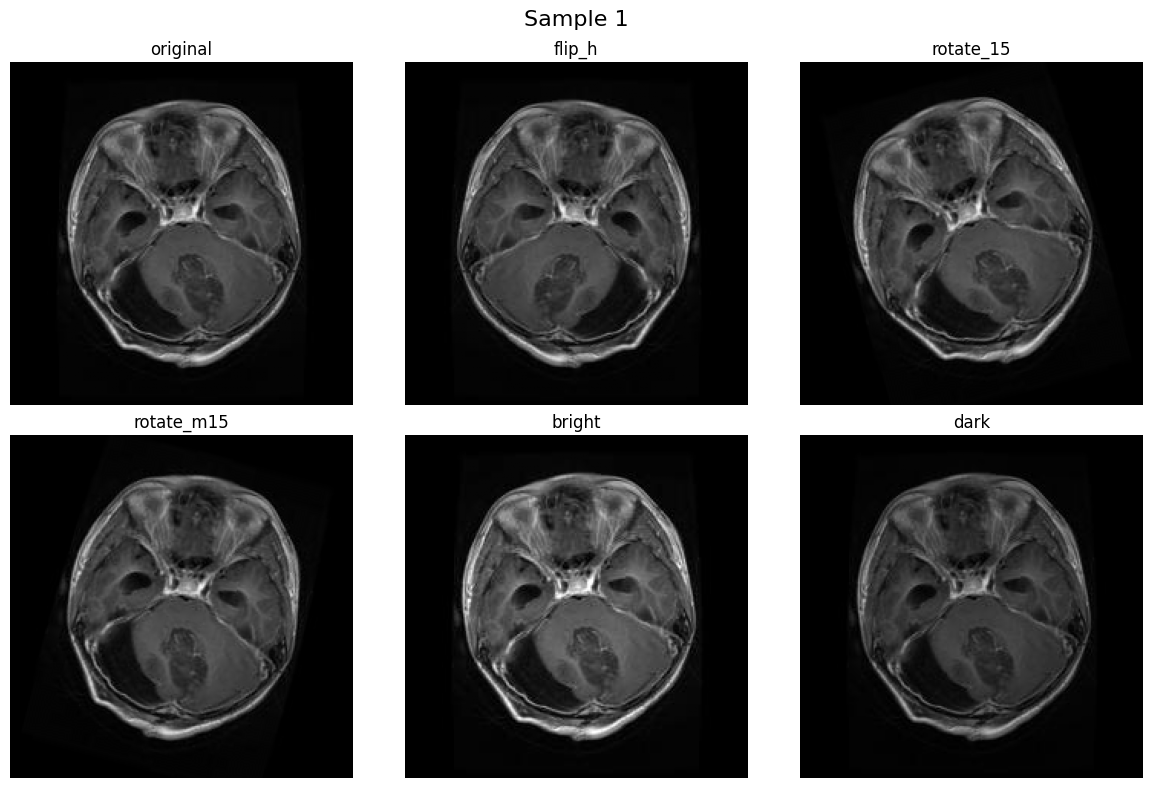

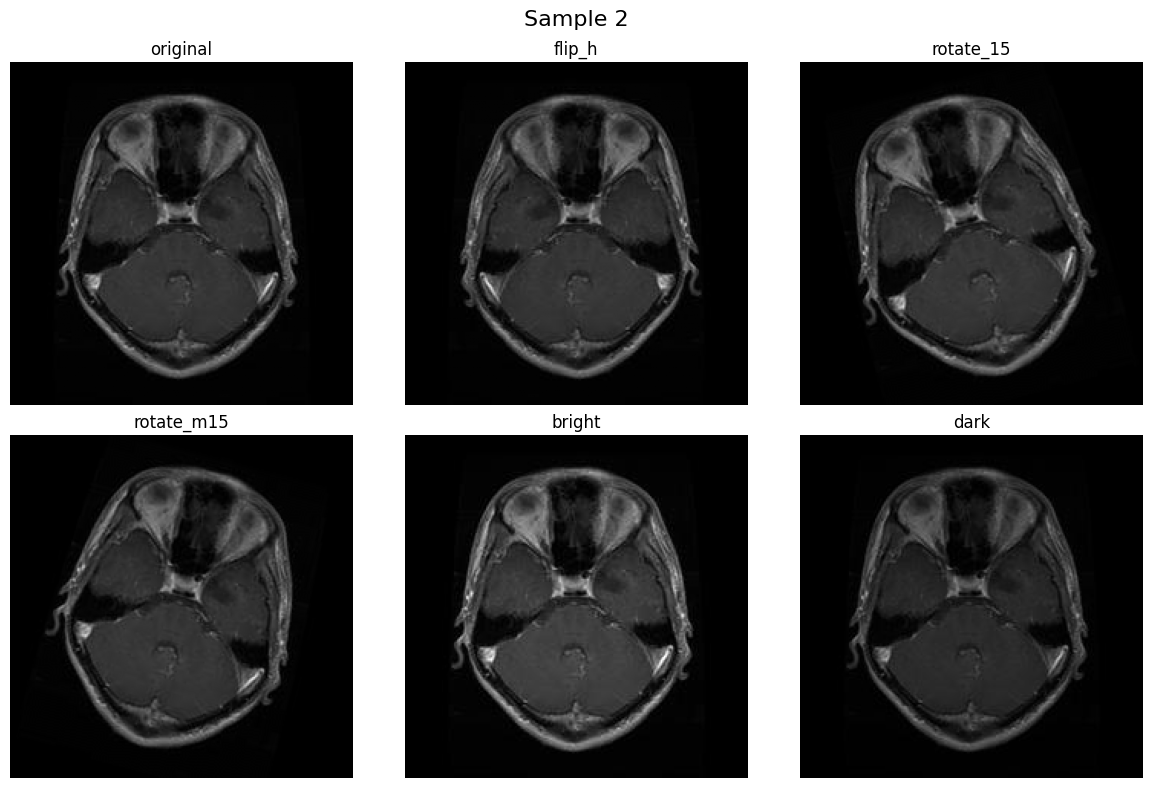

glioma: 9247 images
meningioma: 9373 images
notumor: 11137 images
pituitary: 10199 images
Total augmented images: 39956


In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

def augment_image(img):
    augmented = [('original', img)]
    augmented.append(('flip_h', np.fliplr(img)))
    augmented.append(('rotate_15', ndimage.rotate(img, 15, reshape=False)))
    augmented.append(('rotate_m15', ndimage.rotate(img, -15, reshape=False)))
    augmented.append(('bright', np.clip(img * 1.2, 0, 1)))
    augmented.append(('dark', np.clip(img * 0.8, 0, 1)))
    return augmented

def augment_dataset(src, tgt, limit_per_class=None):
    if not os.path.exists(tgt):
        os.makedirs(tgt)
    total_orig = total_aug = 0
    for root, dirs, files in os.walk(src):
        npy_files = [f for f in files if f.endswith('.npy')]
        if npy_files:
            class_count = 0
            rel_path = os.path.relpath(root, src)
            target_sub = os.path.join(tgt, rel_path)
            os.makedirs(target_sub, exist_ok=True)
            for file in npy_files:
                if limit_per_class and class_count >= limit_per_class:
                    break
                img_array = np.load(os.path.join(root, file))
                for aug_type, aug_img in augment_image(img_array):
                    save_name = f"{file.replace('.npy','')}_{aug_type}.npy"
                    np.save(os.path.join(target_sub, save_name), aug_img)
                    total_aug += 1
                total_orig += 1
                class_count += 1
    print(f"Original: {total_orig}, Augmented: {total_aug}, Expansion: {total_aug//total_orig}x")
    return total_orig, total_aug

def visualize_augmentations(src, num_samples=2):
    samples = []
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.endswith('.npy'):
                samples.append(os.path.join(root, file))
                if len(samples) >= num_samples:
                    break
        if len(samples) >= num_samples:
            break
    for idx, img_path in enumerate(samples):
        img_array = np.load(img_path)
        augmented = augment_image(img_array)
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        fig.suptitle(f'Sample {idx+1}', fontsize=16)
        for i, (name, aug_img) in enumerate(augmented):
            axes[i//3, i%3].imshow(aug_img)
            axes[i//3, i%3].set_title(name)
            axes[i//3, i%3].axis('off')
        plt.tight_layout()
        plt.savefig(f'augmentation_sample_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

def get_augmented_stats(folder):
    stats = {}
    for root, dirs, files in os.walk(folder):
        npy_files = [f for f in files if f.endswith('.npy')]
        if npy_files:
            stats[os.path.basename(root)] = len(npy_files)
    for k,v in stats.items():
        print(f"{k}: {v} images")
    print(f"Total augmented images: {sum(stats.values())}")

# Paths
NORMALIZED_FOLDER = "normalized_dataset"
AUGMENTED_FOLDER = "augmented_dataset"

# Augmentation
total_orig, total_aug = augment_dataset(NORMALIZED_FOLDER, AUGMENTED_FOLDER, limit_per_class=300)
visualize_augmentations(NORMALIZED_FOLDER, num_samples=2)
get_augmented_stats(AUGMENTED_FOLDER)


TensorFlow: 2.20.0 GPU: []
(4000, 224, 224, 3) float32
Train: 2800, Val: 600, Test: 600


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4433 - loss: 1.2980
Epoch 1: val_accuracy improved from None to 0.78167, saving model to best_brain_tumor_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5654 - loss: 1.0547 - val_accuracy: 0.7817 - val_loss: 0.6613
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7635 - loss: 0.6647
Epoch 2: val_accuracy improved from 0.78167 to 0.84500, saving model to best_brain_tumor_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7814 - loss: 0.6114 - val_accuracy: 0.8450 - val_loss: 0.4745
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8285 - loss: 0.4862
Epoch 3: val_accuracy improved from 0.84500 to 0.88833, saving model to best_brain_tumor_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8375 - loss: 0.4712 - val_accuracy: 0.8883 - val_loss: 0.3708
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8679 - loss: 0.3840
Epoch 4: val_accurac

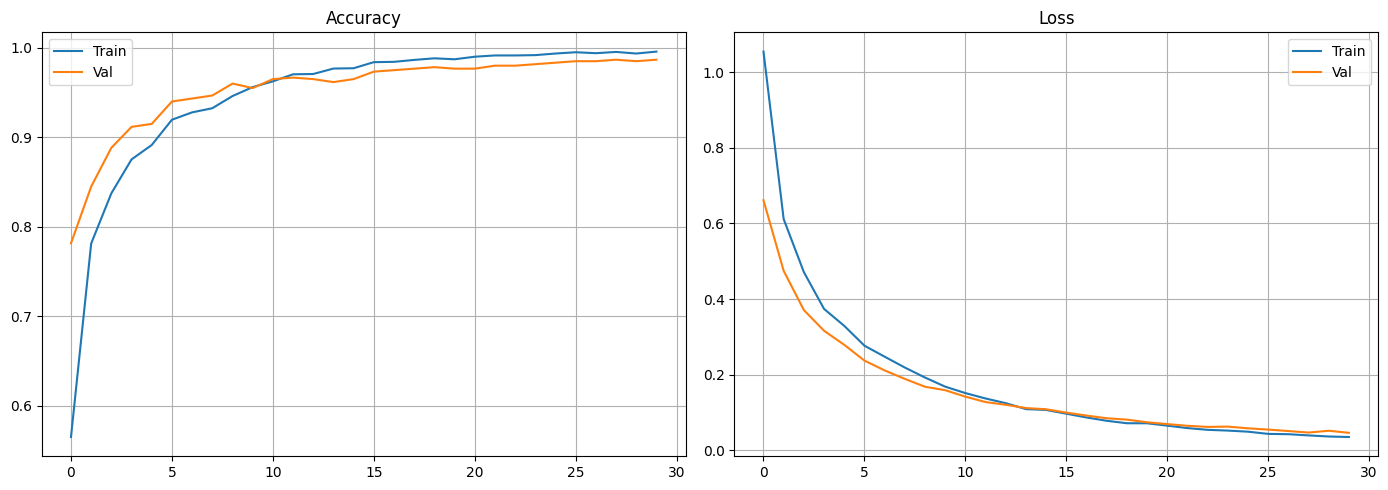

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 820ms/step
Test Loss: 0.0426, Accuracy: 99.00%
              precision    recall  f1-score   support

      glioma       1.00      0.99      1.00       150
  meningioma       0.98      0.98      0.98       150
     notumor       0.99      1.00      1.00       150
   pituitary       0.99      0.99      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



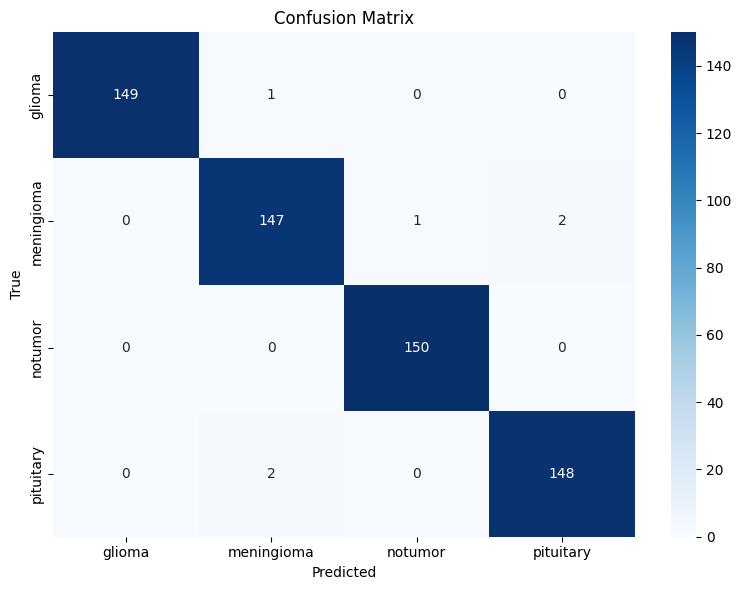

✅ Final Test Accuracy: 99.00%


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__, "GPU:", tf.config.list_physical_devices('GPU'))

def load_dataset(folder, max_per_class=1000):
    images, labels = [], []
    classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
    c2i = {c: i for i, c in enumerate(classes)}

    for root, dirs, files in os.walk(folder):
        f = os.path.basename(root).lower()
        if f in classes:
            count = 0
            for file in files:
                if file.endswith('.npy'):
                    if count >= max_per_class:
                        break
                    img = np.load(os.path.join(root, file))
                    if img.shape == (224, 224, 3):
                        images.append(img.astype(np.float32))
                        labels.append(c2i[f])
                        count += 1
                    else:
                        print(f"Skipping {file}: unexpected shape {img.shape}")

    return np.array(images, dtype=np.float32), np.array(labels), classes


def build_model(num_classes=4, input_shape=(224, 224, 3)):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def train_model(model, X_train, y_train, X_val, y_val, epochs=15):
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    ckpt = ModelCheckpoint('best_brain_tumor_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[es, ckpt]
    )
    return history


def plot_history(hist):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(hist.history.get('accuracy', []), label='Train')
    ax[0].plot(hist.history.get('val_accuracy', []), label='Val')
    ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(hist.history.get('loss', []), label='Train')
    ax[1].plot(hist.history.get('val_loss', []), label='Val')
    ax[1].set_title('Loss'); ax[1].legend(); ax[1].grid(True)
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()


def plot_cm(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()


def evaluate_model(model, X_test, y_test, classes):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}, Accuracy: {acc*100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=classes))
    plot_cm(y_true, y_pred, classes)
    return acc


DATA_FOLDER = "augmented_dataset"
EPOCHS = 30
NUM_CLASSES = 4

X, y, classes = load_dataset(DATA_FOLDER, max_per_class=500)
print(X.shape, X.dtype)

y_cat = to_categorical(y, NUM_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, 1)
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

model = build_model(NUM_CLASSES)
model.summary()

history = train_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS)
plot_history(history)
acc = evaluate_model(model, X_test, y_test, classes)

model.save('brain_tumor_multiclass_model.keras')
np.save('class_names.npy', classes)
print(f"✅ Final Test Accuracy: {acc*100:.2f}%")

In [2]:
for layer in model.layers:
    if 'conv' in layer.name.lower():
        print(layer.name)

Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
Conv_1
Conv_1_bn


c:\Users\hp\miniconda3\envs\cv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


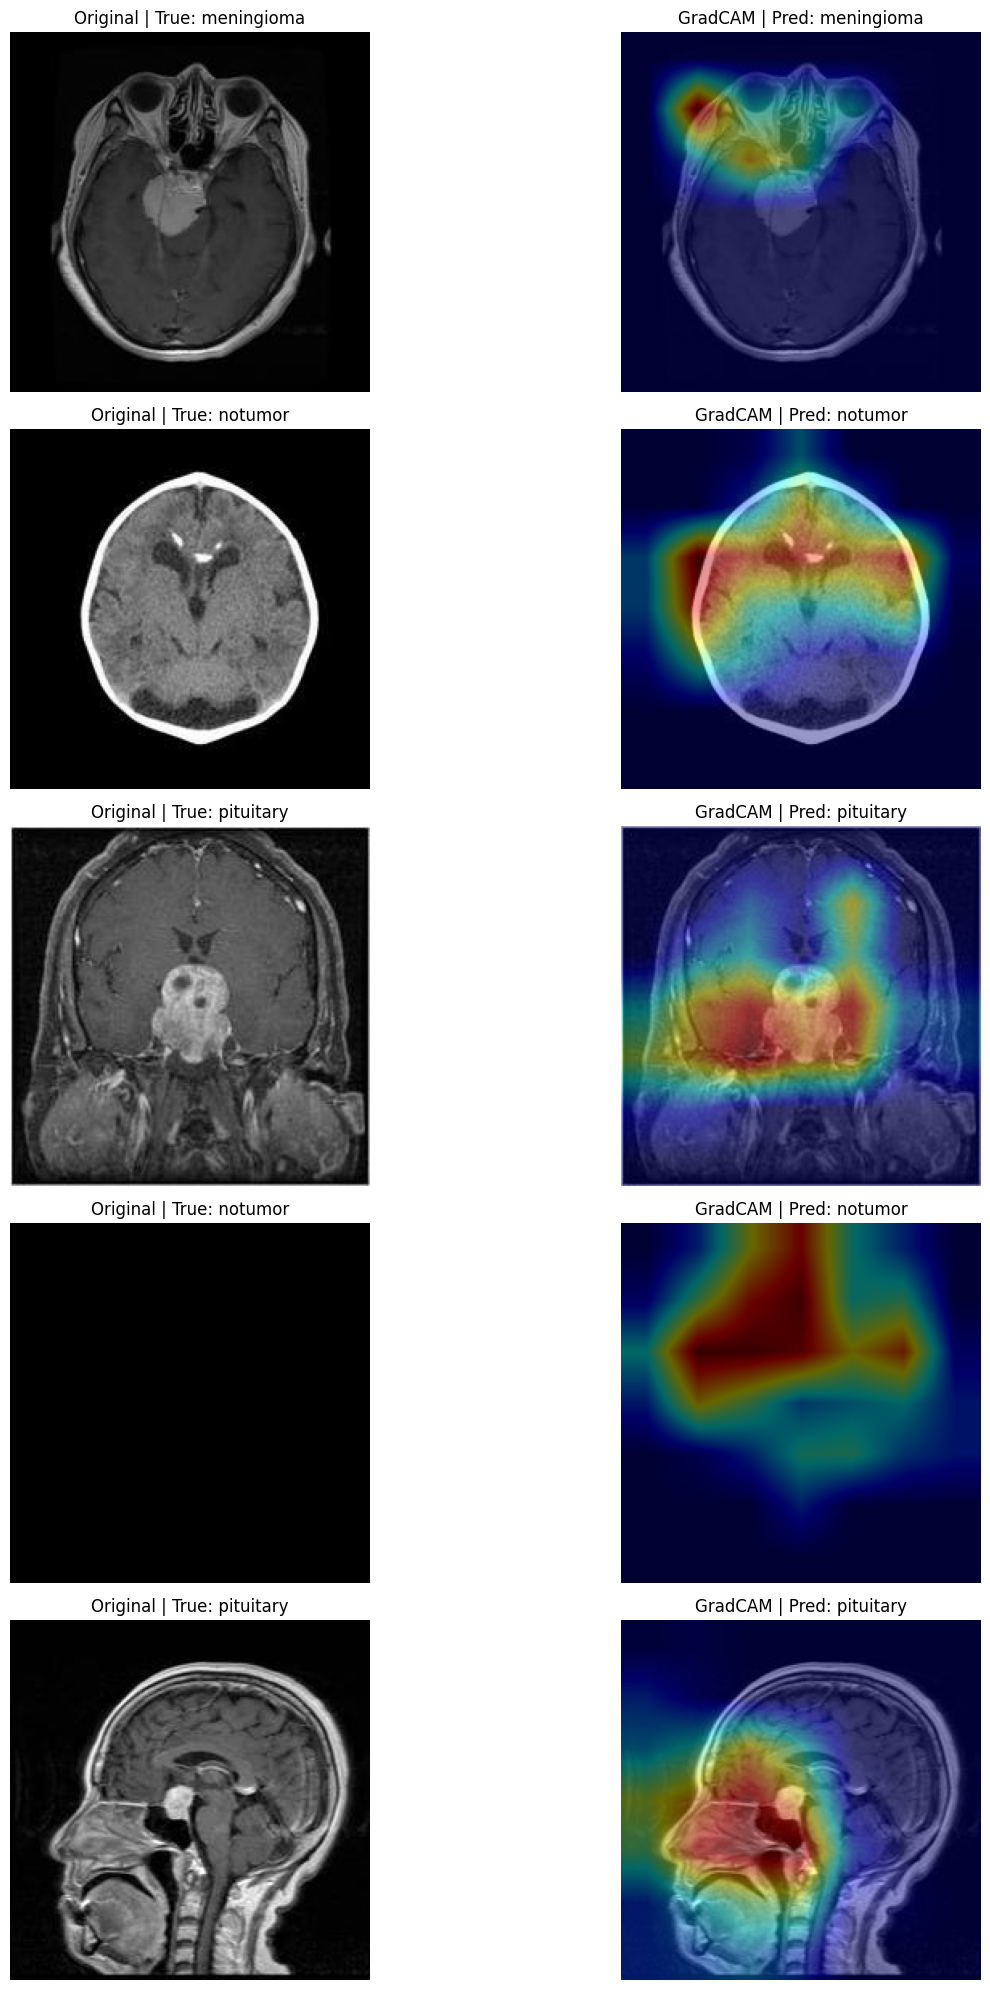

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    if img.max() <= 1.0:
        img_uint8 = np.uint8(255 * img)
    else:
        img_uint8 = np.uint8(img)
    superimposed = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

def visualize_gradcam(model, X_test, y_test, classes, num_images=5):
    last_conv_layer = 'Conv_1_bn'
    plt.figure(figsize=(15, num_images * 4))
    for i in range(num_images):
        img = X_test[i]
        true_label = classes[np.argmax(y_test[i])]
        pred_label = classes[np.argmax(model.predict(img[np.newaxis, ...], verbose=0))]
        heatmap = make_gradcam_heatmap(img[np.newaxis, ...], model, last_conv_layer)
        superimposed = overlay_gradcam(img, heatmap)

        plt.subplot(num_images, 2, 2*i + 1)
        plt.imshow(img if img.max() <= 1.0 else np.uint8(img))
        plt.title(f'Original | True: {true_label}')
        plt.axis('off')

        plt.subplot(num_images, 2, 2*i + 2)
        plt.imshow(superimposed)
        plt.title(f'GradCAM | Pred: {pred_label}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_results.png', dpi=150)
    plt.show()


visualize_gradcam(model, X_test, y_test, classes, num_images=5)

In [1]:
import os

for root, dirs, files in os.walk("original_dataset"):
    for file in files:
        if file.endswith((".jpg",".png",".jpeg")):
            print(os.path.join(root,file))
            break
    break

In [3]:
model.save_weights('model_weights.weights.h5')
print("Done! File saved at:", __import__('os').getcwd())

NameError: name 'model' is not defined